# Análise Espacial de Dados Vetoriais
### Relações topológicas, distância, joins espaciais e agregação

*Emanuel Goulart — today*

::: {.callout-tip appearance="simple"}
Prefere rodar tudo num notebook em vez de acompanhar pelo site? [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/fundamentals_gis_rs/week1/spatial_analysis_of_vectors.ipynb) abre o esse notebook no colab.
 
:::

In [3]:
#| include: false
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geobr
import osmnx as ox
import h3
from shapely.geometry import Polygon
from shapely.affinity import rotate, scale
import folium

import time
import osmnx as ox
import shapely
from scipy.stats import gaussian_kde



## Análise Espacial em Dados Vetoriais

Esse notebook explora as operações espaciais mais usadas no dia a dia como as relações topológicas, distância, joins espaciais, agregação, zoneamento e transformações geométricas.

Para o nosso estudo de casa, vamos utilizar a cidade de *Sinop* no *Mato Grosso*, combinando duas fontes de dados:

- **`geobr`** — escolas (INEP) e estabelecimentos de saúde (CNES), dados oficiais e já geolocalizados.
- **OpenStreetMap** (via `osmnx`) — a malha viária, para explorar interseções e conectividade.

::: {.callout-note appearance="simple"}
Escolhemos Sinop arbitrariamente, é uma cidade média, longe do eixo Rio-São Paulo que domina a maioria dos exemplos de GIS por aí. Sinta-se livre pra trocar o `code_muni` abaixo pela sua própria cidade e rodar tudo de novo.
:::

In [2]:
code_muni = 5107909  # Sinop, MT
CRS_PROJETADO = "EPSG:31981"  # SIRGAS2000 / UTM zone 21S 

sinop = geobr.read_municipality(code_muni=code_muni, year=2020)
schools = geobr.read_schools(year=2020, code_muni=code_muni)
health = geobr.read_health_facilities(date=202304, code_muni=code_muni)

# Vamos já projetar elas para a nossa zona UTM 21 S
code_muni = 5107909  # Sinop, MT
CRS_PROJETADO = "EPSG:31981"  # SIRGAS2000 / UTM zone 21S 

sinop_proj = sinop.to_crs(CRS_PROJETADO)
schools_proj = schools.to_crs(CRS_PROJETADO)
health_proj = health.to_crs(CRS_PROJETADO)

print(f"{len(schools)} escolas, {len(health)} estabelecimentos de saúde")

78 escolas, 635 estabelecimentos de saúde


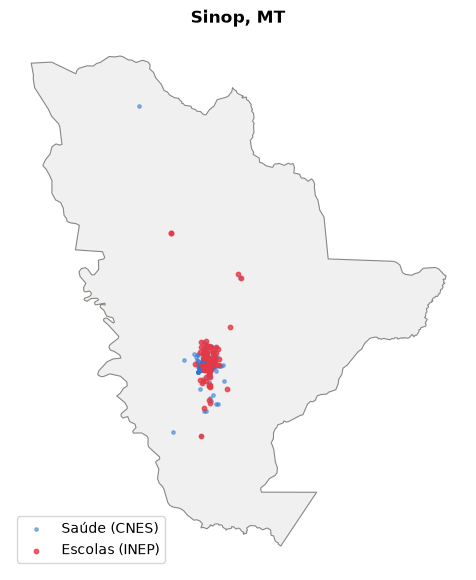

In [49]:

fig, ax = plt.subplots(figsize=(7, 7))
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
health.plot(ax=ax, markersize=6, color="#2a78d6", alpha=0.5, label="Saúde (CNES)")
schools.plot(ax=ax, markersize=10, color="#e63946", alpha=0.8, label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Sinop, MT", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

In [4]:
schools.columns

Index(['code_muni', 'name_muni', 'code_school', 'name_school', 'abbrev_state',
       'tp_dependencia', 'tp_categoria_escola_privada',
       'tp_situacao_funcionamento', 'tp_localizacao',
       'tp_localizacao_diferenciada', 'ds_endereco', 'nu_endereco',
       'ds_complemento', 'no_bairro', 'co_cep', 'code_state', 'name_state',
       'code_region', 'name_region', 'lat_inep', 'lon_inep', 'lat_geocodebr',
       'lon_geocodebr', 'precisao_geocodebr', 'tipo_resultado_geocodebr',
       'desvio_metros_geocodebr', 'coords_source', 'year', 'geometry'],
      dtype='str')

In [5]:
import folium

m = folium.Map(
    location=[sinop.iloc[0].geometry.centroid.y, sinop.iloc[0].geometry.centroid.x],
    zoom_start=12
)

folium.GeoJson(
    sinop,
    name="Limite do município",
    style_function=lambda _: {"fillOpacity": 0, "color": "#333333", "weight": 2},
).add_to(m)

rede_map = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
cores_rede = {1: "#2a78d6", 2: "#e63946", 3: "#2a9d8f", 4: "#f4a261"}

schools_map = schools.copy()
schools_map["rede"] = schools_map["tp_dependencia"].map(rede_map)

# aqui adicionamos as escolas no folium 
folium.GeoJson(
    schools_map,
    name="Escolas (Dados do INEP)",
    marker=folium.CircleMarker(radius=6, fill=True),
    style_function=lambda feat: {
        "fillColor": cores_rede.get(feat["properties"]["tp_dependencia"], "#999999"),
        "color": "white",
        "weight": 0.6,
        "fillOpacity": 0.8,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name_school", "rede"],
        aliases=["Escola:", "Rede:"],
        localize=True,
    ),
).add_to(m)

# CNES tp_unidade cobre dezenas de códigos.  mapeamos (claude mapeou) os que aparecem em Sinop com as respectivas representacoes
tipo_unidade_map = {
    2: "Centro de Saúde/UBS", 
    4: "Policlínica", 
    5: "Hospital Geral",
    22: "Consultório Isolado", 
    36: "Clínica/Centro de Especialidade",
    39: "SADT Isolado", 
    40: "Unidade Móvel Pré-Hospitalar", 
    43: "Farmácia",
    50: "Vigilância Epidemiológica", 
    68: "Central de Notificação/Regulação",
    69: "Central de Regulação Médica de Urgências", 
    70: "Central de Regulação do Acesso",
    72: "Centro de Atenção Psicossocial", 73: "Centro de Apoio à Saúde da Família",
    74: "Pronto Atendimento", 77: "Central de Regulação de Alta Complexidade",
    80: "Laboratório de Saúde Pública", 81: "Central de Gestão em Saúde",
    84: "Central de Abastecimento", 85: "Centro de Imunização",
}

# aqui uma funcao map para corresponder de indice a nome da unidade de saude
health_map = health.copy()
health_map["tipo"] = health_map["tp_unidade"].map(tipo_unidade_map).fillna("Outro")

folium.GeoJson(
    health_map,
    name="Saúde (CNES)",
    marker=folium.CircleMarker(radius=4, fill=True),
    style_function=lambda _: {
        "fillColor": "#2a78d6",
        "color": "white",
        "weight": 0.6,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["no_fantasia", "tipo"],
        aliases=["Estabelecimento:", "Tipo:"],
        localize=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)
m

## Operações Geométricas

Operações geométricas refere-se a um conjunto de métodos que são utlizados para analisar e processar feições geométricas. Ele portanto corrobora em responder como dois ou mais objectos geograficos se relacionam entre si? eles se sobrepoem? se tocam? alguma intersecção? quão longe estão entre eles? 

### Centroid

Centroide é o centro de massa da geometria, seja ela linha, polígono ou geometry collection. Extrair esse centróide é muito útil em diversos casos, como por exemplo para localizar 'labels' na figura, para servir de base em operações espaciais de outros polígonos e etc. Se você tentar calcular o centróide em um CRS não projetado, geopandas calcula mesmo assim, mas avisa que o resultado pode estar errado: grau não é uma unidade de distância uniforme, então o "centro de massa" calculado direto em lat/lon fica levemente deslocado do centro geométrico real. Os dados precisam estar projetados em um sistema de coordenadas projetado (UTM por exemplo) pra esse cálculo fazer sentido de verdade.

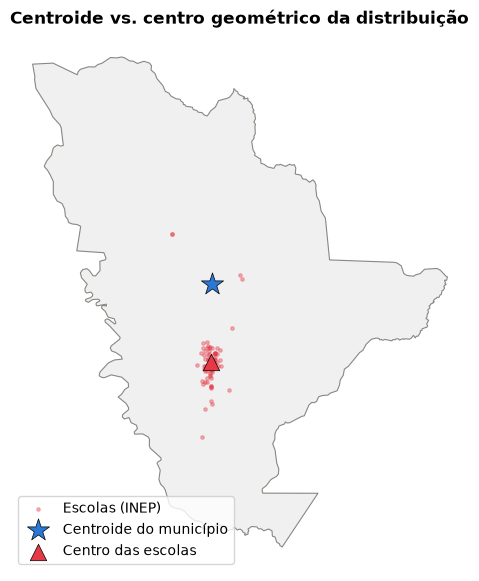

In [50]:
#| label: fig-centroid-d
#| fig-cap: "Centroide do polígono de Sinop (estrela) e centro geométrico da distribuição de escolas (triângulo) -- ambos calculados já em CRS projetado."

centroide_sinop = sinop_proj.geometry.centroid.iloc[0]
centro_escolas = schools_proj.geometry.union_all().centroid

# de volta pro CRS geográfico só pra plotar junto com o resto
centroide_sinop_geo = gpd.GeoSeries([centroide_sinop], crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]
centro_escolas_geo = gpd.GeoSeries([centro_escolas], crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]

fig, ax = plt.subplots(figsize=(7, 7))
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
schools.plot(ax=ax, markersize=6, color="#e63946", alpha=0.35, label="Escolas (INEP)")
ax.scatter(centroide_sinop_geo.x, centroide_sinop_geo.y, marker="*", s=280,
           color="#2a78d6", edgecolor="black", linewidth=0.5, zorder=5, label="Centroide do município")
ax.scatter(centro_escolas_geo.x, centro_escolas_geo.y, marker="^", s=140,
           color="#e63946", edgecolor="black", linewidth=0.5, zorder=5, label="Centro das escolas")
ax.legend(loc="lower left")
ax.set_title("Centroide vs. centro geométrico da distribuição", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

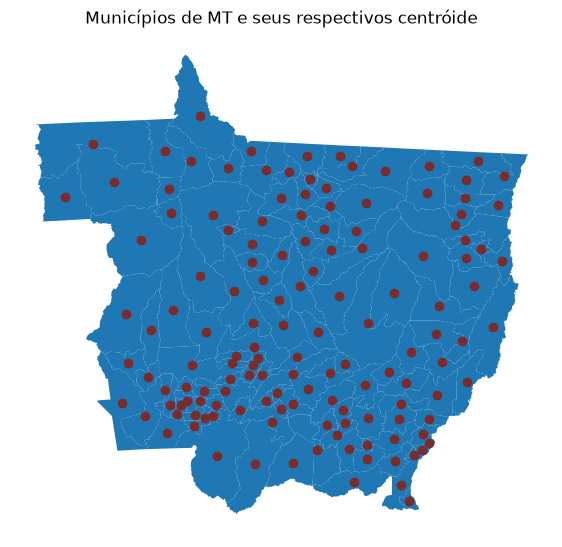

In [7]:
#| label: fig-centroid
#| fig-cap: "Centroide dos municipios de mato grosso"

muni = geobr.read_municipality(year=2020)

# projetando no SIRGAS 2000 UTM 23 S
muni = muni.to_crs('EPSG:31983')
muni_mt = muni.loc[muni['abbrev_state']=='MT']

## project to UTM 22S
muni_mt['centroide'] = muni_mt.geometry.centroid

fig, ax = plt.subplots(figsize=(7,7))
muni_mt.plot(ax=ax)
muni_mt.geometry.centroid.plot(ax=ax,color="#7c2b2b")
ax.set_axis_off()
ax.set_title('Municípios de MT e seus respectivos centróide')
plt.show()

### Buffer

Buffer é uma operação geométrica que cria uma zona ao redor de uma dada geometria, geralmente representando uma distância (raio de cobertura, zona de segurança, área de influência). Combinar buffer com interseção responde perguntas do tipo "que áreas estão cobertas mais de uma vez?" — por exemplo, existe algum ponto em Sinop dentro do raio de 1 km de *duas* escolas ao mesmo tempo?

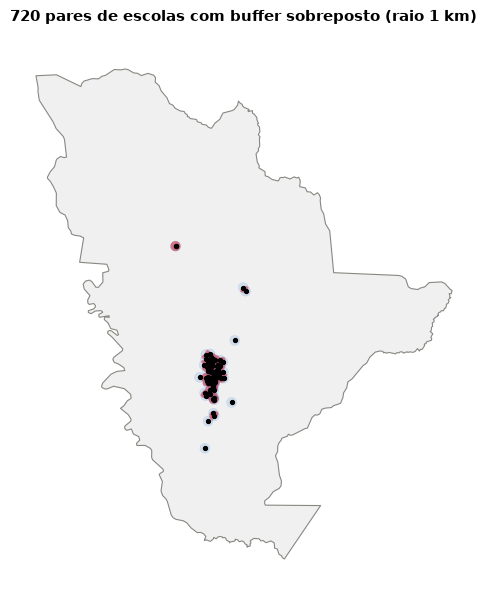

In [8]:
#| label: fig-buffer-overlap
#| fig-cap: "Buffer de 1 km ao redor de cada escola, no núcleo urbano de Sinop. Em vermelho, as regiões cobertas por duas ou mais escolas ao mesmo tempo."

buffers = schools_proj[["code_school", "geometry"]].copy()
buffers["geometry"] = buffers.buffer(1000)  # 1 km de raio

# cruza os buffers com eles mesmos; code_school_1 < code_school_2 evita
# contar a interseção de um buffer com ele mesmo e duplicar cada par (A∩B == B∩A)
pares = gpd.overlay(buffers, buffers, how="intersection")
pares = pares[pares["code_school_1"] < pares["code_school_2"]]
cobertura_dupla = pares.union_all()

# zoom na região onde as sobreposições acontecem, em vez do município (~60 km) inteiro
# minx, miny, maxx, maxy = cobertura_dupla.bounds
# folga = 1500

fig, ax = plt.subplots(figsize=(7, 7))
sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
buffers.plot(ax=ax, color="#2a78d6", alpha=0.15, edgecolor="#2a78d6", linewidth=0.4)
gpd.GeoSeries([cobertura_dupla], crs=CRS_PROJETADO).plot(ax=ax, color="#e63946", alpha=0.6)
schools_proj.plot(ax=ax, markersize=8, color="black")
# ax.set_xlim(minx - folga, maxx + folga)
# ax.set_ylim(miny - folga, maxy + folga)
ax.set_title(f"{len(pares)} pares de escolas com buffer sobreposto (raio 1 km)", fontsize=11, fontweight="bold")
ax.set_axis_off()
plt.show()

In [15]:
schools_buffer_geo = buffers.to_crs("EPSG:4326")

health_buffers = health_proj[["co_cnes", "no_fantasia", "geometry"]].copy()
health_buffers["geometry"] = health_buffers.buffer(1000)  # 1 km de raio
health_buffers_geo = health_buffers.to_crs("EPSG:4326")

## create a new folium map 
m = folium.Map(
    location=[sinop.iloc[0].geometry.centroid.y, sinop.iloc[0].geometry.centroid.x],
    zoom_start=13,
)

buffers_geo = buffers.to_crs("EPSG:4326") # reprojetando para um sistema WGS84 - GEOGRAFICO

folium.GeoJson(
    buffers_geo,
    name="Buffers (1 km)",
    style_function=lambda _: {
        "fillColor": "#2a78d6", "color": "#2a78d6", "weight": 0.5, "fillOpacity": 0.15,
    },
).add_to(m)

# aqui adicionamos as escolas no folium 
folium.GeoJson(
    schools_map,
    name="Escolas (Dados do INEP)",
    marker=folium.CircleMarker(radius=6, fill=True),
    style_function=lambda feat: {
        "fillColor": cores_rede.get(feat["properties"]["tp_dependencia"], "#999999"),
        "color": "white",
        "weight": 0.6,
        "fillOpacity": 0.8,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name_school", "rede"],
        aliases=["Escola:", "Rede:"],
        localize=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)
m


### União e Dissolve

Algumas operações serve para unir as geometrias ou dissolve-las a um nível de agregação para formar outros. Você pode dissolver as geometrias das cidades para formar um estado ou região, por exemplo. Olhando de perto, `union_all()` funde todas as geometrias em única geometria. Ele faz isso sem olhar pra nenhum atributo. Já o `dissolve(by=...)` faz a mesma fusão por baixo dos panos, mas primeiro agrupa as linhas pelo dado atributo. As duas funções tem como parâmetro o método `method`: `"unary"` (padrão, robusto, funciona mesmo com geometrias sobrepostas) ou `"coverage"` ,bem mais rápido, mas só vale pra polígonos que já formam uma cobertura sem sobreposição, tipo limites administrativos vizinhos, se você usa as geometrias do CAR aqui vai ser encrenca.

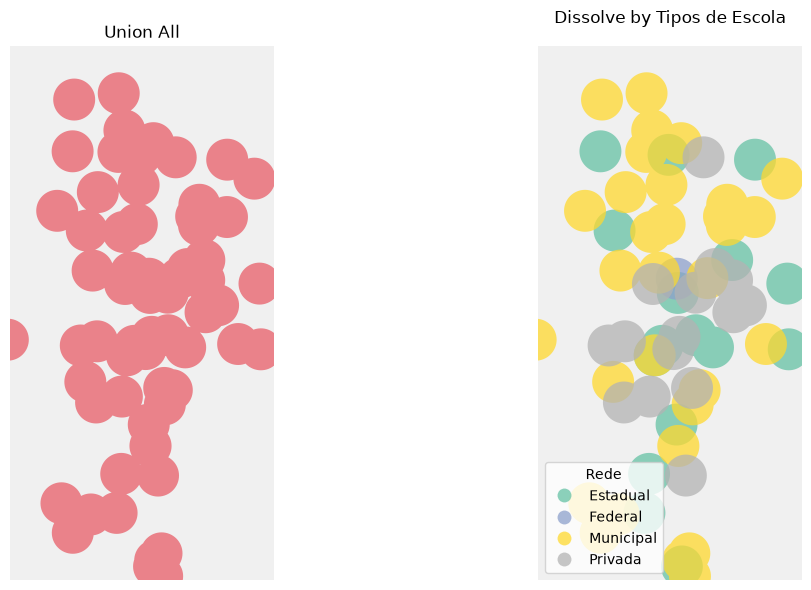

In [16]:
#| label: fig-dissolve
#| fig-cap: "Área de influência (buffer de 400 m) de cada escola, no núcleo urbano de Sinop. À esquerda, union_all() funde tudo numa geometria só. À direita, dissolve(by='rede') agrupa antes de unir, preservando a rede de ensino."

dependencia_map = {1: "Federal", 
                    2: "Estadual",
                     3: "Municipal", 
                     4: "Privada"}
schools_proj["rede"] = schools_proj["tp_dependencia"].map(dependencia_map)

influencia = schools_proj[["rede", 
                            "geometry"]].copy()
influencia["geometry"] = influencia.buffer(400)

uniao_total = influencia.union_all()

# aqui dissolvendo pelos tipos de escola
dissolve_por_rede = influencia.dissolve(by="rede").reset_index()

# os buffers (400 m) somem de vista numa figura do município inteiro (~60 km) --
# damos zoom no maior na area central da cidade (onde contem mais pontos) resultante da união, que é exatamente o núcleo
# urbano denso (as escolas isoladas na zona rural viram círculos minúsculos à parte)
maior_blob = max(uniao_total.geoms, key=lambda g: g.area)
minx, miny, maxx, maxy = maior_blob.bounds
folga = 500

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax in axes:
    sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.6)
    ax.set_xlim(minx - folga, maxx + folga)
    ax.set_ylim(miny - folga, maxy + folga)
    ax.set_axis_off()

gpd.GeoSeries([uniao_total], crs=CRS_PROJETADO).plot(ax=axes[0], color="#e63946", alpha=0.6)
axes[0].set_title("Union All")

dissolve_por_rede.plot(ax=axes[1], column="rede", categorical=True, cmap="Set2",
                        alpha=0.75, legend=True, legend_kwds={"title": "Rede", "loc": "lower left"})
axes[1].set_title("Dissolve by Tipos de Escola")

plt.tight_layout()
plt.show()

In [11]:
dissolve_por_rede.geometry.area

0    9.474952e+06
1    5.018478e+05
2    1.552256e+07
3    6.659887e+06
dtype: float64

### Convex Hull

O convex hull é o menor polígono convexo que contém todos os pontos de um conjunto. Imagine esticar um elástico em volta de todos os pontos e deixar ele encolher até tocar só nos mais externos. Vamos ilustrar isso a partir dos pontos das escolas de Sinop.

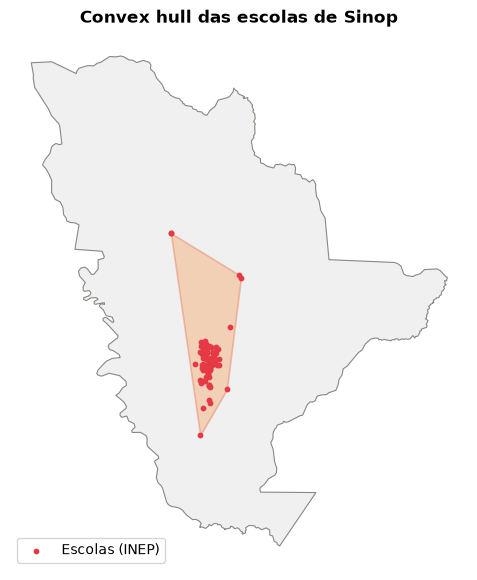

In [17]:
#| label: fig-convex-hull
#| fig-cap: "Convex hull das escolas de Sinop: o menor polígono convexo que contém todos os pontos."

hull = schools_proj.geometry.union_all().convex_hull

fig, ax = plt.subplots(figsize=(7, 7))
sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
gpd.GeoSeries([hull], crs=CRS_PROJETADO).plot(ax=ax, color="#f4a261", alpha=0.4, edgecolor="#e76f51", linewidth=1.2)
schools_proj.plot(ax=ax, markersize=10, color="#e63946", label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Convex hull das escolas de Sinop", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

## Relações topológicas

Relações topológicas servem para compreender como duas geometrias se relacionam no espaço: `intersects` (encosta em qualquer parte), `within` (está totalmente dentro), `touches` (encosta só na borda, sem sobrepor), `disjoint` (não tem relação nenhuma). Repare que `intersects` é simétrica (se X intersecta Y, Y intersecta X), mas `within`/`contains` não são.

Vamos usar isso pra classificar as escolas de Sinop em **urbanas** (dentro de um raio de 2,5 km do centro) e **rurais** (fora dele).

In [18]:
# estabelecendo um ponto no centro de Sinop
centro = gpd.GeoSeries(
    [gpd.points_from_xy([-55.5089], [-11.8642])[0]], crs="EPSG:4326"
).to_crs(CRS_PROJETADO)

area_urbana = centro.buffer(5000).iloc[0]  # 5 km, já em metros

## aqui a analise topologica
## se a escola esta dentro da area urbana ( nosso buffer the 5km) entao urbana, senao rural 
schools_proj["zona"] = np.where(schools_proj.within(area_urbana), "urbana", "rural")

# printa o numero de escolas na area urbana 
print(schools_proj["zona"].value_counts())


zona
urbana    66
rural     12
Name: count, dtype: int64


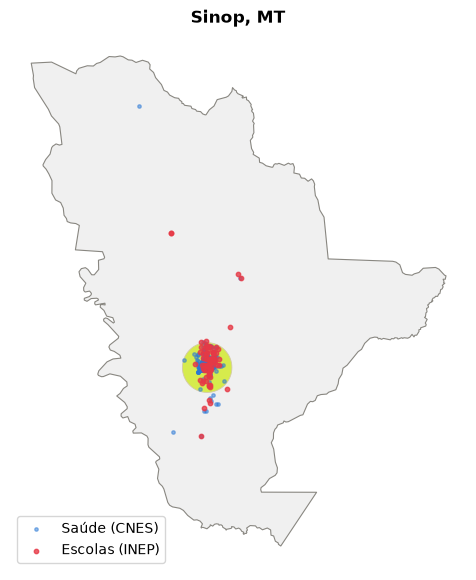

In [19]:
## Agora vamos plots 
fig, ax = plt.subplots(figsize=(7, 7))

# delineacao do municipio 
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)

# area_urbana é um shapely Polygon "puro", não um GeoDataFrame
# por isso não tem .plot(); e está em CRS_PROJETADO (metros), então reprojetamos de volta
# pro CRS geográfico de sinop/schools/health antes de plotar, senão as escalas não batem
area_urbana_geo = gpd.GeoSeries([area_urbana], 
                    crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]
# o truque pra quando nao eh geopandas, ou entao converta para geopandas
ax.fill(*area_urbana_geo.exterior.xy, 
            color="#cdea0eb9",          
          edgecolor="#d4caa7", 
            linewidth=0.6)

health.plot(ax=ax, markersize=6, color="#2a78d6", alpha=0.5, label="Saúde (CNES)")

schools.plot(ax=ax, markersize=10, color="#e63946", alpha=0.8, label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Sinop, MT", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

::: {.callout-note appearance="simple"}
Não mosca!

Se você ainda não está a vontade com as relações topológicas, então da uma olhada na nossa aula de python+GIS, onde olhamos com muito mais calma e a fundo essas relações. Aula 1 e Aula 2. [Python+GIS](https://github.com/ftl-brazil-2026/gis-python-basics/blob/main/python_gis_1.ipynb)
:::

### Transformações afins

Rotação, escala, translação e cisalhamento — operações que distorcem uma geometria sem recalcular nada a partir dos dados originais, só aplicando uma matriz na geometria já existente. Útil pra ajustar geometrias mal-alinhadas ou simplesmente pra entender o que cada operação faz:

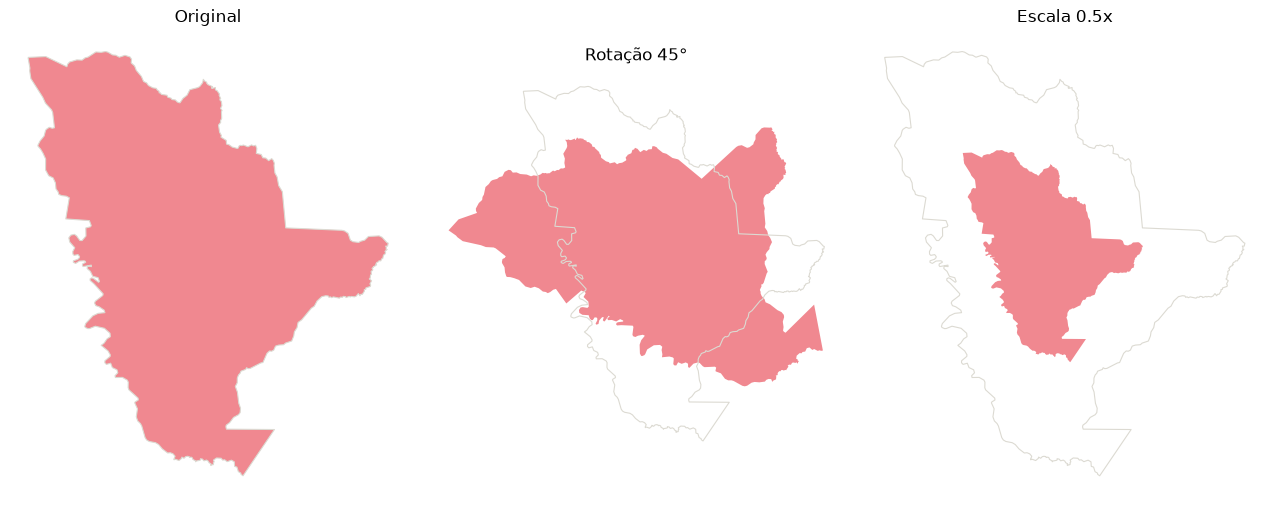

In [22]:
#| label: fig-affine
#| fig-cap: "A mesma geometria (limite de Sinop): original, rotacionada 45° e escalada pela metade — sempre em torno do próprio centro."

geom = sinop_proj.geometry.iloc[0]

geom_rotacionada = rotate(geom, 45, origin="centroid")
geom_escalada = scale(geom, xfact=0.5, yfact=0.5, origin="centroid")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, g, title in zip(
    axes, [geom, geom_rotacionada, geom_escalada], ["Original", "Rotação 45°", "Escala 0.5x"]
):
    gpd.GeoSeries([geom], crs=CRS_PROJETADO).boundary.plot(ax=ax, color="#dcdad2", linewidth=0.8)
    gpd.GeoSeries([g], crs=CRS_PROJETADO).plot(ax=ax, color="#e63946", alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## Relações de distância

Diferente das relações topológicas que são por natureza boleanas (verdadeiro/falso), relações de **distância** são contínuas. Além disso, existem algumas nuances que precisam ser consideradas dependendo do tipo de vetor que estamos analisando. Certamento a distancia entre dois points é a famosa distância euclideana, muito já batida e amassada pela algebra linear.

![Source:Wikipedia - Euclidean Distance](images/Euclidean_distance_2d.svg){fig-align="center"}

Contudo, observamos a distancia entre duas retas, ou a distancia entre um ponto e um polígono, e então a nuance toma conta. Vamos considerar que a distância entre um ponto e um polígono mais próximas entre os dois elementos. 

![Source:Arcgis - Arcmap Documentacao](images/GUID-6FD5566F-FE23-4289-AA6D-AC1A6CA0CF6E-web.png){fig-align="center"}



Mão na massa:

### **qual a distância de cada escola até o estabelecimento de saúde mais próximo?**

In [51]:
## Importante aqui, olha para a reducao utilizando o minimo
dist_para_saude = schools_proj.geometry.apply(
    lambda pt: health_proj.distance(pt).min()
)

print(f"Distância média até a saúde mais próxima: {dist_para_saude.mean():.0f} m")
print(f"Escola mais isolada: {dist_para_saude.max():.0f} m")
print(f"Escola mais proxima: {dist_para_saude.min():.0f} m")

Distância média até a saúde mais próxima: 732 m
Escola mais isolada: 16743 m
Escola mais proxima: 2 m


## Spatial Join

![Screenshot 2026-08-27 at 16.06.34.png](<attachment:Screenshot 2026-08-27 at 16.06.34.png>)

Source: [Spatial Join - Python GIS](https://pythongis.org/part2/chapter-06/nb/06-spatial-join.html)
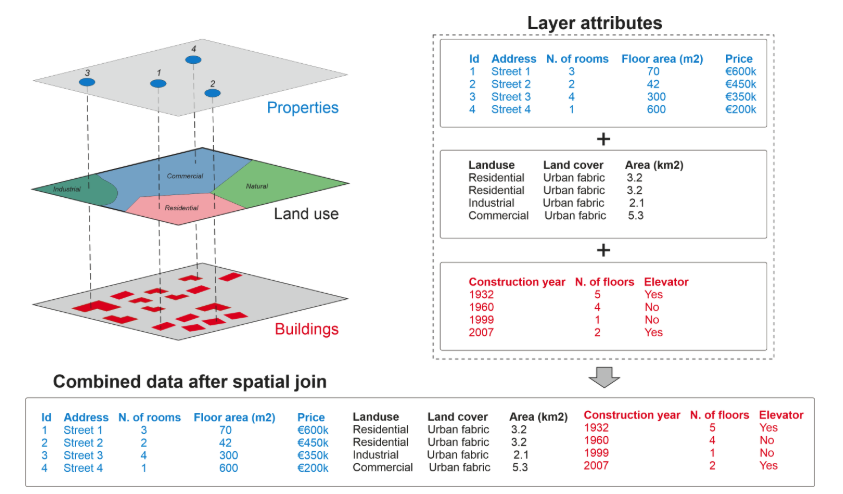

In [52]:
# gpd.sjoin junta atributos com base numa relação espacial (within predicado usado aqui),

saude_buffers = health_proj[["no_fantasia", "geometry"]].copy()
saude_buffers["geometry"] = saude_buffers.buffer(1000)  # 1 km de raio de cobertura

escolas_cobertas = gpd.sjoin(schools_proj, saude_buffers, predicate="within")

print(f"{escolas_cobertas['code_school'].nunique()} de {len(schools_proj)} escolas estão "
      f"dentro do raio de cobertura de pelo menos um estabelecimento de saúde")
escolas_cobertas[["name_school", "no_fantasia"]].head()

74 de 78 escolas estão dentro do raio de cobertura de pelo menos um estabelecimento de saúde


,name_school,no_fantasia
0,ESCOLA CENECISTA SANTA ELISABETE,SINOP MED
0,ESCOLA CENECISTA SANTA ELISABETE,CARRERA
0,ESCOLA CENECISTA SANTA ELISABETE,SOMA PSICOLOGIA
0,ESCOLA CENECISTA SANTA ELISABETE,G S SERVICOS MEDICOS
0,ESCOLA CENECISTA SANTA ELISABETE,AGENCIA TRANSFUSIONAL HEMOSAN SINOP


## Joins espaciais por distância

Um **join espacial** funciona como um join de atributos (tema batido para quem conhece tabelas relacionais), só que o critério de join é uma relação espacial em vez de uma chave em comum. `sjoin_nearest` responde a pergunta do capítulo anterior, mas devolve um `GeoDataFrame`, com a opção de limitar a um raio máximo (`max_distance`), o que é útil pra não juntar pontos longe demais de fazer sentido:

In [24]:
schools_com_saude = gpd.sjoin_nearest(
    schools_proj,
    health_proj[["geometry", "no_fantasia"]],
    distance_col="dist_saude_mais_proxima",
    max_distance=5000,  # não junta nada além de 5 km
)

schools_com_saude[["name_school", "no_fantasia", "dist_saude_mais_proxima"]].sort_values(
    "dist_saude_mais_proxima", ascending=False
).head(5)

,name_school,no_fantasia,dist_saude_mais_proxima
9,EMEB SILVANA,UNIDADE DE SAUDE DA FAMILIA ENDIRA PICHLER TES...,4790.005070
35,EE BOM JARDIM,UNIDADE BASICA DE SAUDE SAO FRANCISCO,1925.651095
63,EMEI CAMPING CLUBE,UBS CAMPING CLUB,909.113620
42,EMEI GERSON PIRES DA SILVA,UNIDADE DE SAUDE DA FAMILIA JARDIM IBIRAPUERA,773.870893
10,EMEB UILIBALDO VIEIRA GOBBO,UNIDADE DE SAUDE DA FAMILIA PARQUE DAS ARARAS,626.982180


## Agregação espacial

**Agregação espacial** resume valores de um objeto (o "alvo") agrupando pela geometria de outro (a "fonte").  A geometria da fonte é quem define os grupos, e o resultado herda a geometria *dela*, não a do alvo. Vamos agregar pelo grupo mais simples que já temos: urbana vs. rural.

In [25]:
resumo_zona = (
    schools_com_saude
    .groupby("zona")
    .agg(
        n_escolas=("code_school", "count"),
        dist_media_saude=("dist_saude_mais_proxima", "mean"),
        dist_max_saude=("dist_saude_mais_proxima", "max"),
        # faca aqui a minima distancia 
    )
    .round(0)
)
resumo_zona

,n_escolas,dist_media_saude,dist_max_saude
zona,,,
rural,10,979.0,4790.0
urbana,98,185.0,774.0


# Nearest Neighboors (Vizinhos mais proximos)

Nearest Neighboors começa a tratar de um ponto importante da análise de dados espaciais, a relação de um ponto em respeito aos seus vizinhos. 

Isso vem de uma noção construída pela primeira Lei da Geografia proposta por Tobler.

### A Primeira Lei da Geografia

> "Everything is related to everything else, but near things are more related than distant things."
> — Waldo Tobler, 1970

Essa frase — hoje conhecida como a **Primeira Lei da Geografia** de Tobler — é basicamente a justificativa de por que "proximidade" é uma das perguntas mais básicas (e mais úteis) que dá pra fazer sobre dado espacial. "Qual é o ponto mais próximo?" parece trivial, mas é a base de coisas como: qual escola atende esse bairro, onde fica a parada de ônibus mais perto de casa, quão bem distribuído está um serviço público pela cidade.

[Descrição do conceito de Tobler](https://math.univ-lyon1.fr/~alachal/diaporamas/diaporama_cartographie3/Tobler_First_Law_Geography.htm)

![neearest neighboor](<attachment:Screenshot 2026-08-27 at 16.59.17.png>)
Fonte: [Python GIS Course](https://pythongis.org/part2/chapter-06/nb/06-spatial-join.html)
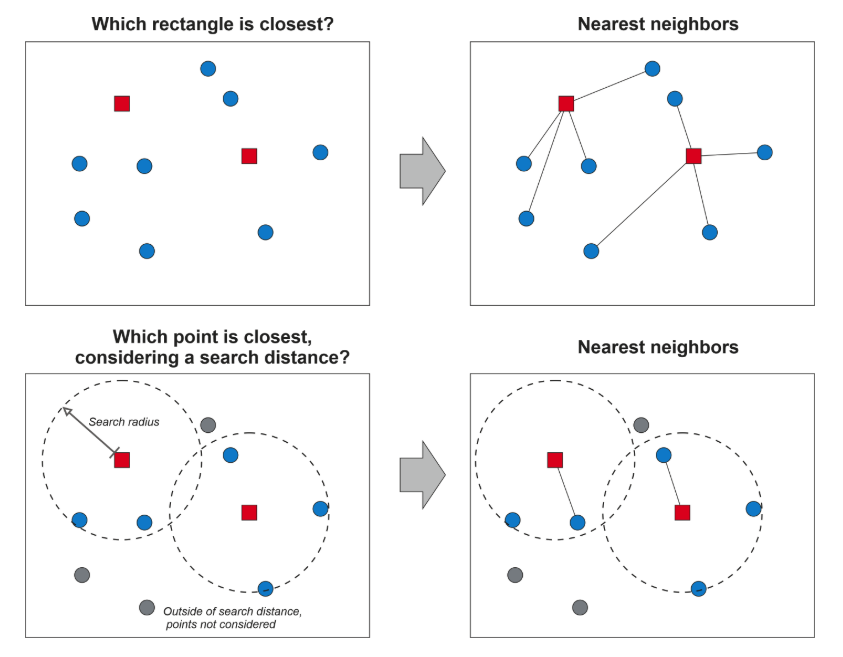

In [ ]:

import time
from shapely import shortest_line
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde
from folium.plugins import HeatMap

::: {.callout-note appearance="simple"}
Sinop tem poucos pontos de ônibus mapeados no OpenStreetMap -- comum em cidades menores/mais novas, onde o mapeamento colaborativo de transporte público ainda é escasso. Pra essa análise de vizinho mais próximo, precisamos de uma malha de pontos de ônibus mais densa: trocamos para **Maceió, Alagoas**, mantendo as escolas via `geobr`.
:::

In [6]:
CRS_PROJETADO = "EPSG:31985"  # SIRGAS2000 / UTM zone 25S  - Maceió, AL
code_muni = 2704302  # Maceió, AL

maceio = geobr.read_municipality(code_muni=code_muni, year=2020)
escolas = geobr.read_schools(year=2020, code_muni=code_muni)

# pontos de ônibus, direto do OSM, dentro do polígono do município
pontos_onibus = ox.features_from_polygon(maceio.iloc[0].geometry, tags={"highway": "bus_stop"})
pontos_onibus = pontos_onibus[pontos_onibus.geom_type == "Point"].reset_index(drop=True)

print(f"{len(pontos_onibus)} pontos de ônibus, {len(escolas)} escolas")

239 pontos de ônibus, 556 escolas


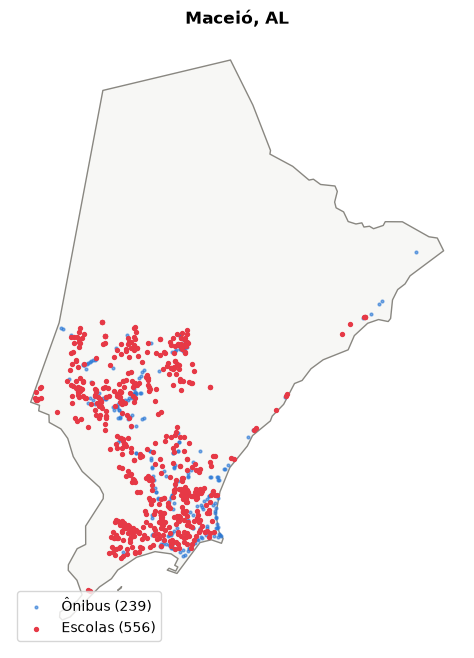

In [7]:
#| label: fig-overview-nn
#| fig-cap: "Maceió, AL: pontos de ônibus (OSM) e escolas (INEP/geobr)."

fig, ax = plt.subplots(figsize=(8, 8))
maceio.plot(ax=ax, color="#f7f7f5", edgecolor="#898781", linewidth=1)
pontos_onibus.plot(ax=ax, markersize=4, color="#2a78d6", alpha=0.6, label=f"Ônibus ({len(pontos_onibus)})")
escolas.plot(ax=ax, markersize=8, color="#e63946", label=f"Escolas ({len(escolas)})")
ax.legend(loc="lower left")
ax.set_title("Maceió, AL", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

## O vizinho mais próximo

Antes de usar qualquer função pronta, vale entender o que "vizinho mais próximo" realmente significa: pra **um** ponto de ônibus, calcular a distância até **todas** as escolas, e pegar a menor.

In [8]:
onibus_proj = pontos_onibus.to_crs(CRS_PROJETADO)
escolas_proj = escolas.to_crs(CRS_PROJETADO)

# aqui pega apenas o primeiro ponto
um_ponto = onibus_proj.geometry.iloc[0]

# calcula a distancia de todas as escolas para esse ponto
distancias = escolas_proj.geometry.distance(um_ponto)

print(f"Escola mais próxima desse ponto de ônibus: {distancias.min():.0f} m")
print(f"Escola mais distante desse mesmo ponto:    {distancias.max():.0f} m")

Escola mais próxima desse ponto de ônibus: 201 m
Escola mais distante desse mesmo ponto:    17994 m


Para um ponto é facil, agora como fazer isso pra **todos** os pontos de ônibus, um de cada vez contra todas as escolas? Parece ser na **força bruta**, certo?

In [11]:
t0 = time.time()
resultado_forca_bruta = [
    escolas_proj.geometry.distance(pt).min() for pt in onibus_proj.geometry
]
tempo_forca_bruta = time.time() - t0
print(f"Força bruta: {tempo_forca_bruta:.3f} s para {len(onibus_proj)}×{len(escolas_proj)} comparações")
print(f"\nDistância média até a escola mais próxima: {round(np.mean(resultado_forca_bruta))}")

Força bruta: 0.022 s para 239×556 comparações

Distância média até a escola mais próxima: 282


Nesse tamanho ainda é rápido, mas repare que dobrar os pontos de ônibus **e** dobrar as escolas quadruplica o trabalho. Em cidades inteiras, com centenas de milhares de feições, isso vira um problema de verdade.


Dessa forma, vamos calcular o mesmo resultado de uma forma mais eficiente através do  `sjoin_nearest`, que utiliza indice espacial.

Essa estrutura de índice espacial é resolvida com geopandas (uma R-tree, chamada STRtree por baixo dos panos), em vez de comparar contra todo mundo, ela organiza as geometrias de um jeito que permite descartar regiões inteiras do espaço de uma vez, sem nem calcular a distância pra elas.

In [13]:
t0 = time.time()
onibus_com_escola = gpd.sjoin_nearest(
    onibus_proj,
    escolas_proj[["geometry", "name_school"]],
    distance_col="dist_escola_mais_proxima",
)
tempo_indexado = time.time() - t0

print(f"sjoin_nearest: {tempo_indexado:.3f} s")
print(f"\nDistância média até a escola mais próxima: {onibus_com_escola['dist_escola_mais_proxima'].mean():.0f} m")

sjoin_nearest: 0.011 s

Distância média até a escola mais próxima: 282 m


Mesmo resultado da busca força bruta mas com a metade do tempo. Aqui fizemos isso apenas para 500 dados, imagina para 1 milhão de pontos de onibus.

::: {.callout-note appearance="simple"}
### Empates e duplicatas

Quando duas escolas estão à exatíssima mesma distância de um ponto de ônibus, `sjoin_nearest` devolve **as duas** — o resultado pode ter mais linhas do que o `onibus_proj` original. Vale sempre conferir:
:::

In [15]:
duplicatas = onibus_com_escola.index.duplicated().sum()
print(f"Pontos de ônibus com mais de uma escola empatada como 'mais próxima': {duplicatas}")

Pontos de ônibus com mais de uma escola empatada como 'mais próxima': 0


### Visualizando esses vizinhos mais próximos.

Uma forma direta de validar visualmente se o resultado faz sentido é desenhando uma linha do ponto de ônibus até a escola mais próxima. O `sjoin_nearest` só devolve o índice da escola casada (`index_right`), portanto pra desenhar a linha até ela, precisamos buscar a geometria dela de volta com um `merge`.

In [19]:
escolas_proj[["geometry"]]

,geometry
0,POINT (199543.637 8932250.319)
1,POINT (199427.746 8936482.908)
2,POINT (201121.503 8930934.686)
3,POINT (199307.603 8932927.969)
4,POINT (201341.767 8933549.947)
...,...
551,POINT (201503.821 8944178.511)
552,POINT (198951.231 8931750.787)
553,POINT (196048.017 8944279.171)
554,POINT (198324.469 8942956.51)


In [20]:
# sjoin_nearest devolve só o índice da escola; 
# buscamos a geometria dela de volta com um merge, o que gera geometry_x (ônibus) e geometry_y (escola)
onibus_com_geom_escola = onibus_com_escola.merge(
    escolas_proj[["geometry"]], 
    left_on="index_right", 
    right_index=True, 
    suffixes=("_x", "_y")
)

# aqui usamos umas funcao do shapely que cria a linha dada duas geometrias 
from shapely import shortest_line
conectores = onibus_com_geom_escola.apply(
    lambda row: shortest_line(row["geometry_x"], row["geometry_y"]), axis=1
)

# finalizamos criando um geodataframe com os conectores, utilizando a mesma projecao 
conectores = gpd.GeoDataFrame({"geometry": conectores}, crs=onibus_proj.crs)
conectores["distancia"] = conectores.length
conectores.head()

,geometry,distancia
0,"LINESTRING (199446.742 8934817.855, 199295.492...",201.005749
1,"LINESTRING (200672.189 8930874.292, 200615.906...",126.463200
2,"LINESTRING (202608.369 8936565.816, 201839.145...",921.848474
3,"LINESTRING (193240.989 8944733.572, 193756.381...",728.890882
4,"LINESTRING (200881.882 8933047.242, 200764.686...",366.099030


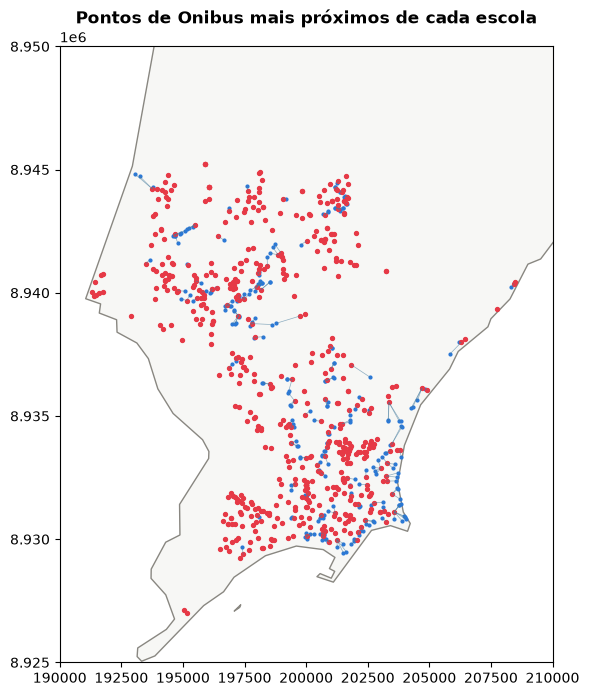

In [35]:

fig, ax = plt.subplots(figsize=(8, 8))
maceio.to_crs(CRS_PROJETADO).plot(ax=ax, color="#f7f7f5", edgecolor="#898781", linewidth=1)
conectores.plot(ax=ax, color="#457b9d", linewidth=0.5, alpha=0.6)
onibus_proj.plot(ax=ax, markersize=4, color="#2a78d6")
escolas_proj.plot(ax=ax, markersize=8, color="#e63946")
ax.set_title("Pontos de Onibus mais próximos de cada escola", fontsize=12, fontweight="bold")
#ax.set_axis_off()
ax.set_xlim(190000,210000)
ax.set_ylim(8.925e6,8.950e6)
plt.show()

## Agrupado ou disperso? O Índice do Vizinho Mais Próximo

Dá pra ir além de "qual é o vizinho mais próximo" e perguntar: **os pontos de ônibus estão espalhados uniformemente pela área, ou concentrados em alguns pontos?** O [ESRI - Average Nearest Neighbor](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/spatial-statistics/h-how-average-nearest-neighbor-distance-spatial-st.html) (Clark & Evans, 1954) compara a distância média observada entre vizinhos mais próximos com a distância média que **esperaríamos** se os pontos estivessem espalhados aleatoriamente (mesma densidade, posições ao acaso):

$$R = \frac{\bar{d}_{observado}}{\bar{d}_{esperado}}, \qquad \bar{d}_{esperado} = \frac{1}{2\sqrt{densidade}}$$


Onde:
- $d_{esperado}$ é a distância esperada
- $d_{observado}$ é a distância observada
- $R < 1$ → os pontos estão **mais agrupados** do que o esperado ao acaso
- $R \approx 1$ → padrão **aleatório**
- $R > 1$ → os pontos estão **mais dispersos/uniformes** do que o esperado ao acaso


Vamos calcular esse índice referente **somente aos nossos dados de ponto de ônibus**. Não estamos envolvendo os pontos referente as escolas. Nosso objetivo é entender se os pontos de onibus estão classificados como agrupaos, dispersos ou aleatório.

![Screenshot 2026-08-27 at 20.14.47.png](<attachment:Screenshot 2026-08-27 at 20.14.47.png>)

[Fonte: ESRI](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/spatial-statistics/average-nearest-neighbor.html?tabs=dialog)

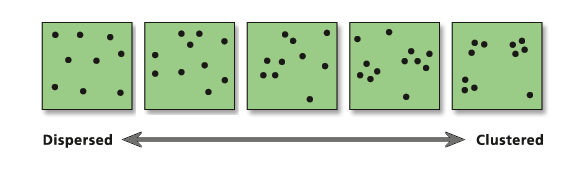

In [38]:
# Nossa distância observada será para cada vizinho mais próximo de cada ponto de ônibus 
# exclusive=True evita que cada ponto "case" com ele mesmo (distância 0) 
# sem isso, o vizinho mais próximo de qualquer ponto seria sempre ele mesmo.
dist_onibus_onibus = gpd.sjoin_nearest(
    onibus_proj, 
    onibus_proj, 
    distance_col="dist_vizinho", 
    exclusive=True,
)

d_observado = dist_onibus_onibus["dist_vizinho"].mean()

area_m2 = maceio.to_crs(CRS_PROJETADO).area.iloc[0]
densidade = len(onibus_proj) / area_m2
d_esperado = 1 / (2 * np.sqrt(densidade))

R = d_observado / d_esperado
print(f"Distância média observada:  {d_observado:.1f} m")
print(f"Distância média esperada (aleatório): {d_esperado:.1f} m")
print(f"Índice R = {R:.2f} ")

Distância média observada:  204.4 m
Distância média esperada (aleatório): 730.9 m
Índice R = 0.28 


## K-Nearest Neighboor (KNN)

Até agora, sempre buscamos só **o** vizinho mais próximo. Mas é comum precisar de mais do que isso, por exemplo "quais são os 3 pontos de ônibus mais próximos dessa escola?".

Já que cada um deles pode oferencer diferentes conexões para as cidades, essa busca por *K* vizinhos mais próximos é chamada de **KNN search** (K-Nearest Neighbors).

O `sjoin_nearest` do GeoPandas usa uma R-tree por baixo dos panos, e essa estrutura só devolve **o** vizinho mais próximo, não os *K* mais próximos. Pra isso, usamos outra estrutura de índice espacial, a **KD-tree** (K-dimensional tree) que é organizada de um jeito um pouco diferente da R-tree, mas que permite justamente esse tipo de busca.

In [4]:
from scipy.spatial import cKDTree

# aqui vamos usar numpy e definições de arrays
# primeiro criamos uma stack
coords_onibus = np.column_stack([onibus_proj.geometry.x, onibus_proj.geometry.y])
coords_escolas = np.column_stack([escolas_proj.geometry.x, escolas_proj.geometry.y])

# agora criamos a k-dimensional tree para os pontos de onibus 
arvore = cKDTree(coords_onibus)

# favorecemos uma query para os tres vizinhos mais próximos
distancias_k, indices_k = arvore.query(coords_escolas, k=3)

print(f"3 pontos de ônibus mais próximos da primeira escola: {distancias_k[0].round(0)} m")

# pergunta, qual a média de distancia de uma escola aos seus 3 pontos de onibus mais próximos?

NameError: name 'onibus_proj' is not defined

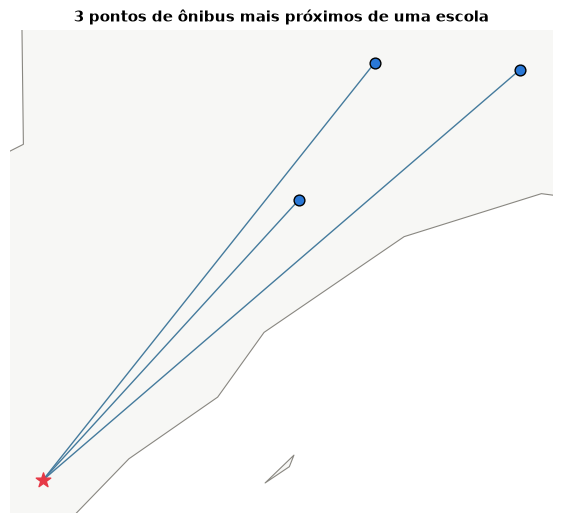

In [58]:

# a escola cujo 3º vizinho mais próximo está mais longe  (só pra dar zoom num caso bem visível)
i = distancias_k[:, -1].argmax()
escola_exemplo = escolas_proj.geometry.iloc[i]
vizinhos_exemplo = onibus_proj.geometry.iloc[indices_k[i]]

fig, ax = plt.subplots(figsize=(7, 7))
maceio.to_crs(CRS_PROJETADO).plot(ax=ax, color="#f7f7f5", edgecolor="#898781", linewidth=0.8)
onibus_proj.plot(ax=ax, markersize=4, color="#2a78d6", alpha=0.3)
vizinhos_exemplo.plot(ax=ax, markersize=60, color="#2a78d6", edgecolor="black", zorder=5)
gpd.GeoSeries([escola_exemplo], crs=CRS_PROJETADO).plot(ax=ax, markersize=120, color="#e63946", marker="*", zorder=5)
for p in vizinhos_exemplo:
    ax.plot([escola_exemplo.x, p.x], [escola_exemplo.y, p.y], color="#457b9d", linewidth=1)

combinado = gpd.GeoSeries(list(vizinhos_exemplo) + [escola_exemplo])
minx, miny, maxx, maxy = combinado.total_bounds
folga = 300
ax.set_xlim(minx - folga, maxx + folga)
ax.set_ylim(miny - folga, maxy + folga)
ax.set_title("3 pontos de ônibus mais próximos de uma escola", fontsize=11, fontweight="bold")
ax.set_axis_off()
plt.show()

## Heat Map (Mapa de calor)

Já vimos duas formas de descrever "proximidade", com o vizinho mais próximo (um valor por ponto) e o índice R (um número resumindo o padrão inteiro). 
O mapa de calor (KDE) fecha essa progressão mostrando *onde*, especificamente, a concentração acontece.

O mapa de calor é uma distribuição espacial com respeito aos pontos, assim, regiões que contém mais pontos agrupados serão regiões mais densas comparadas a regiões esparsas.


Para a formulação, estamos usando uma distribuição gaussiana, através da função gaussian_kde do scipy, modulo spatial.

Essa função utiliza um kernel para estimar a função de probalidade de densidade (probability density function PDF)

Imagine um antro de pontos distribuidos sobre um plano. Podemos visualmente inferir noções a esses pontos como proximidade relativa, alguma percepção de densidade, e uma noção especial de como esses pontos estao distribuidos sobre um dado plano. Imagine posicionar uma suave "colina" sobre cada ponto observado. A KDE (*Kernel Density Estimation*) é a **soma de todas essas colinas**, alta onde as observações se concentram, plana onde são esparsas.

$$\hat{f}(x) = \frac{1}{n h^2} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Onde $K$ é o **kernel** (a forma da colina) e $h$ é a **largura de banda** (*bandwidth*) , o quão larga ela se espalha.

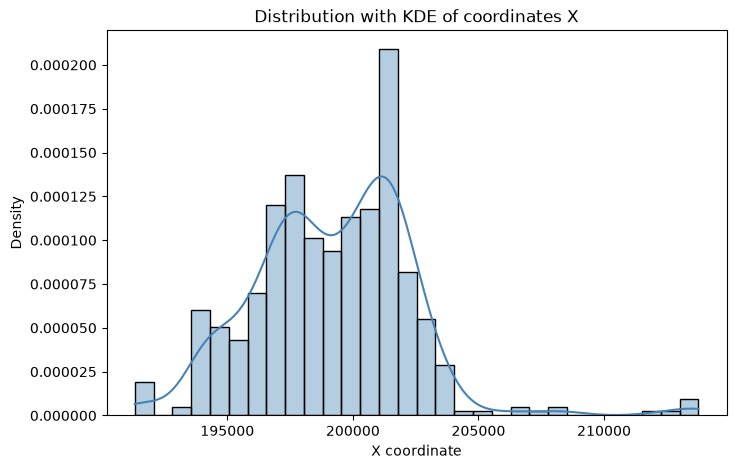

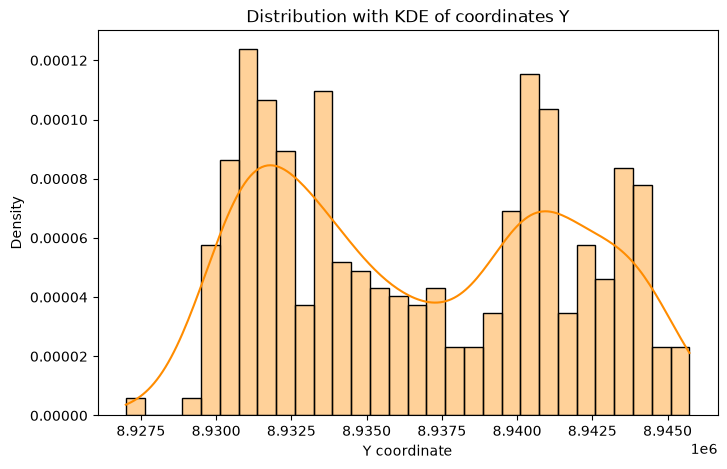

In [77]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# X coordinates
arr_x = escolas_proj.geometry.x.values

plt.figure(figsize=(8, 5))

sns.histplot(
    arr_x,
    bins=30,
    stat="density",
    kde=True,
    color="steelblue",
    alpha=0.4
)

plt.xlabel("X coordinate")
plt.ylabel("Density")
plt.title("Distribution with KDE of coordinates X")
plt.show()


# Y coordinates
arr_y = escolas_proj.geometry.y.values

plt.figure(figsize=(8, 5))

sns.histplot(
    arr_y,
    bins=30,
    stat="density",
    kde=True,
    color="darkorange",
    alpha=0.4
)

plt.xlabel("Y coordinate")
plt.ylabel("Density")
plt.title("Distribution with KDE of coordinates Y")
plt.show()


As distribuições marginais das coordenadas X e Y permitem observar como as escolas estão distribuídas individualmente **em cada dimensão espacial**. Entretanto, analisar essas coordenadas separadamente não permite identificar onde ocorre a concentração espacial dos pontos, uma vez que a localização de cada equipamento depende simultaneamente de suas coordenadas X e Y.

Para representar essa concentração espacial, utiliza-se a Estimativa de Densidade por Kernel (KDE) em duas dimensões. Nesse caso, cada escola ou ponto de ônibus é representado por um par de coordenadas (X, Y), e o KDE estima uma superfície contínua de densidade a partir desses pontos. Assim, regiões com maior concentração de equipamentos apresentam valores de densidade mais elevados, sendo representadas pelas áreas mais quentes no mapa.

Dessa forma, as distribuições unidimensionais das coordenadas X e Y servem como uma introdução à estrutura espacial dos dados, enquanto o KDE bidimensional permite visualizar essa estrutura considerando simultaneamente as duas coordenadas.

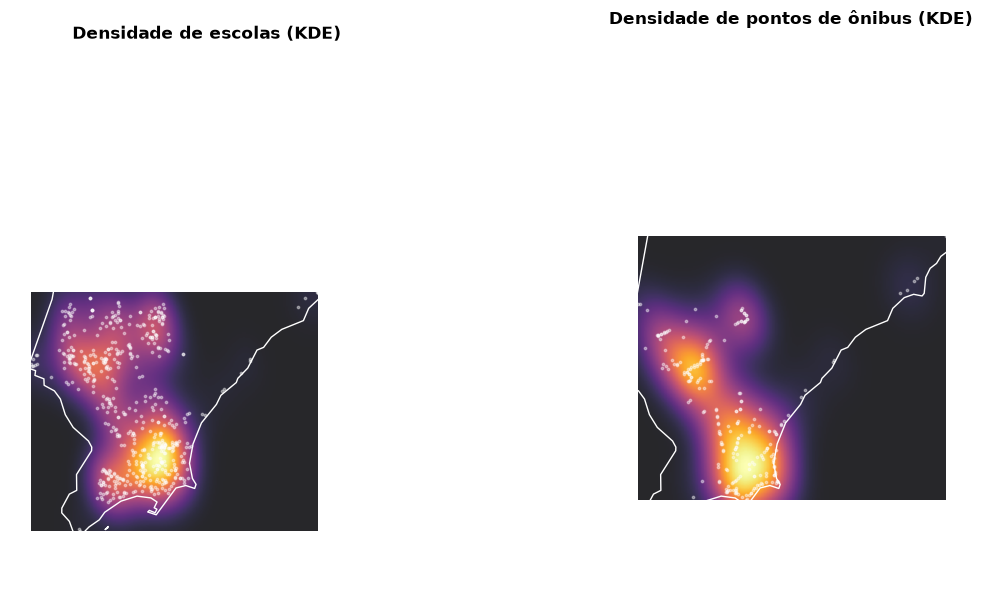

In [59]:
#| label: fig-kde
#| fig-cap: "Densidade de escolas e de pontos de ônibus em Maceió (KDE) -- mais quente onde a concentração é maior."

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pontos, titulo in zip(axes, [escolas_proj, onibus_proj], ["Escolas", "Pontos de ônibus"]):
    coords = np.vstack([pontos.geometry.x, pontos.geometry.y])
    kde = gaussian_kde(coords)
    xmin, ymin, xmax, ymax = pontos.total_bounds
    grid_x, grid_y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    densidade_grid = kde(grid_coords).reshape(grid_x.shape)

    ax.imshow(np.rot90(densidade_grid), cmap="inferno", alpha=0.85, extent=[xmin, xmax, ymin, ymax])
    maceio.to_crs(CRS_PROJETADO).boundary.plot(ax=ax, color="white", linewidth=1)
    pontos.plot(ax=ax, markersize=3, color="white", alpha=0.4)
    ax.set_title(f"Densidade de {titulo.lower()} (KDE)", fontsize=12, fontweight="bold")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

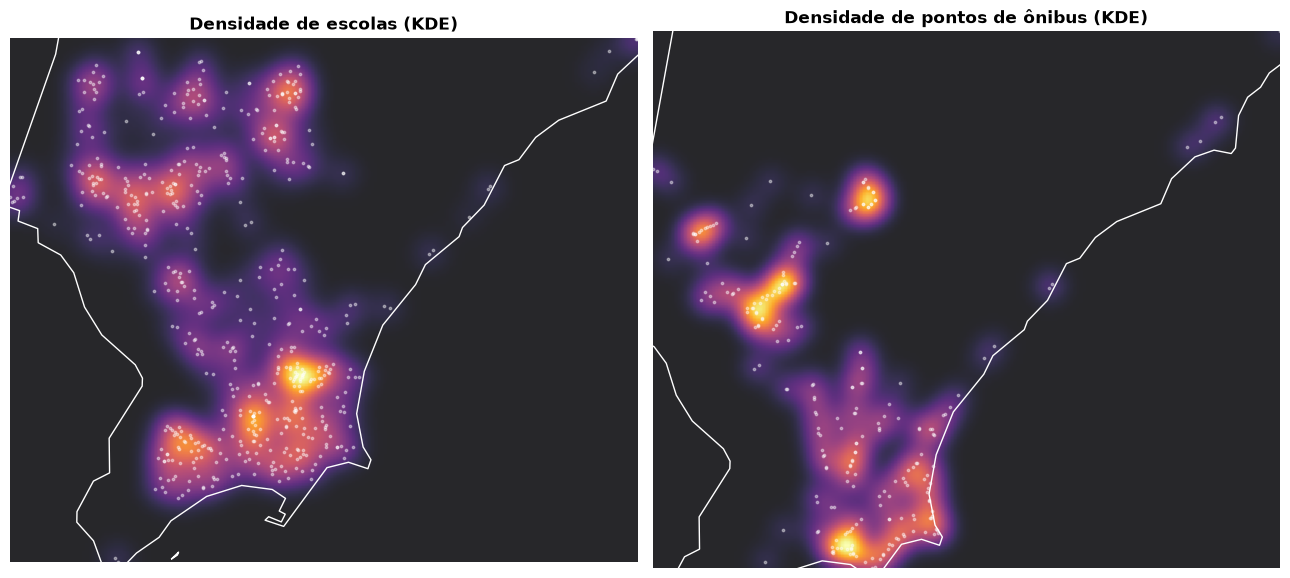

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pontos, titulo in zip(
    axes,
    [escolas_proj, onibus_proj],
    ["Escolas", "Pontos de ônibus"]
):

    # Get X and Y coordinates: shape (N, 2)
    coords = np.column_stack([
        pontos.geometry.x.values,
        pontos.geometry.y.values
    ])

    # Fit 2D Gaussian KDE
    kde = KernelDensity(
        bandwidth=500,
        kernel="gaussian",
        metric="euclidean"
    )

    kde.fit(coords)

    # Spatial extent
    xmin, ymin, xmax, ymax = pontos.total_bounds

    # Create evaluation grid
    grid_x, grid_y = np.meshgrid(
        np.linspace(xmin, xmax, 200),
        np.linspace(ymin, ymax, 200)
    )

    grid_coords = np.column_stack([
        grid_x.ravel(),
        grid_y.ravel()
    ])

    # Estimate density
    log_density = kde.score_samples(grid_coords)

    # Convert log-density to density
    densidade_grid = np.exp(log_density).reshape(grid_x.shape)

    # Plot KDE
    ax.imshow(
        densidade_grid,
        cmap="inferno",
        alpha=0.85,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower"
    )

    # Maceió boundary
    maceio.to_crs(CRS_PROJETADO).boundary.plot(
        ax=ax,
        color="white",
        linewidth=1
    )

    # Original points
    pontos.plot(
        ax=ax,
        markersize=3,
        color="white",
        alpha=0.4
    )

    ax.set_title(
        f"Densidade de {titulo.lower()} (KDE)",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

Bom mas `scipy` é o único jeito de criar um heatmap? Claro que não. Vamos dar boas vindas a nossa companheira biblioteca chamada `sklearn` . Diferente da outra função, sklearn usa um kernel de densitidade que te permite testar diferentes tipos de kernels. Isso nos dá mais flexibilidade do que fitar uma função gaussiana exclusiva. Além do mais, KernelDensity detém um parâmetro chaado bandwith que é essencial para nós. Esse parâmetro define a influência do ponto vizinho na estimação da densidade. 

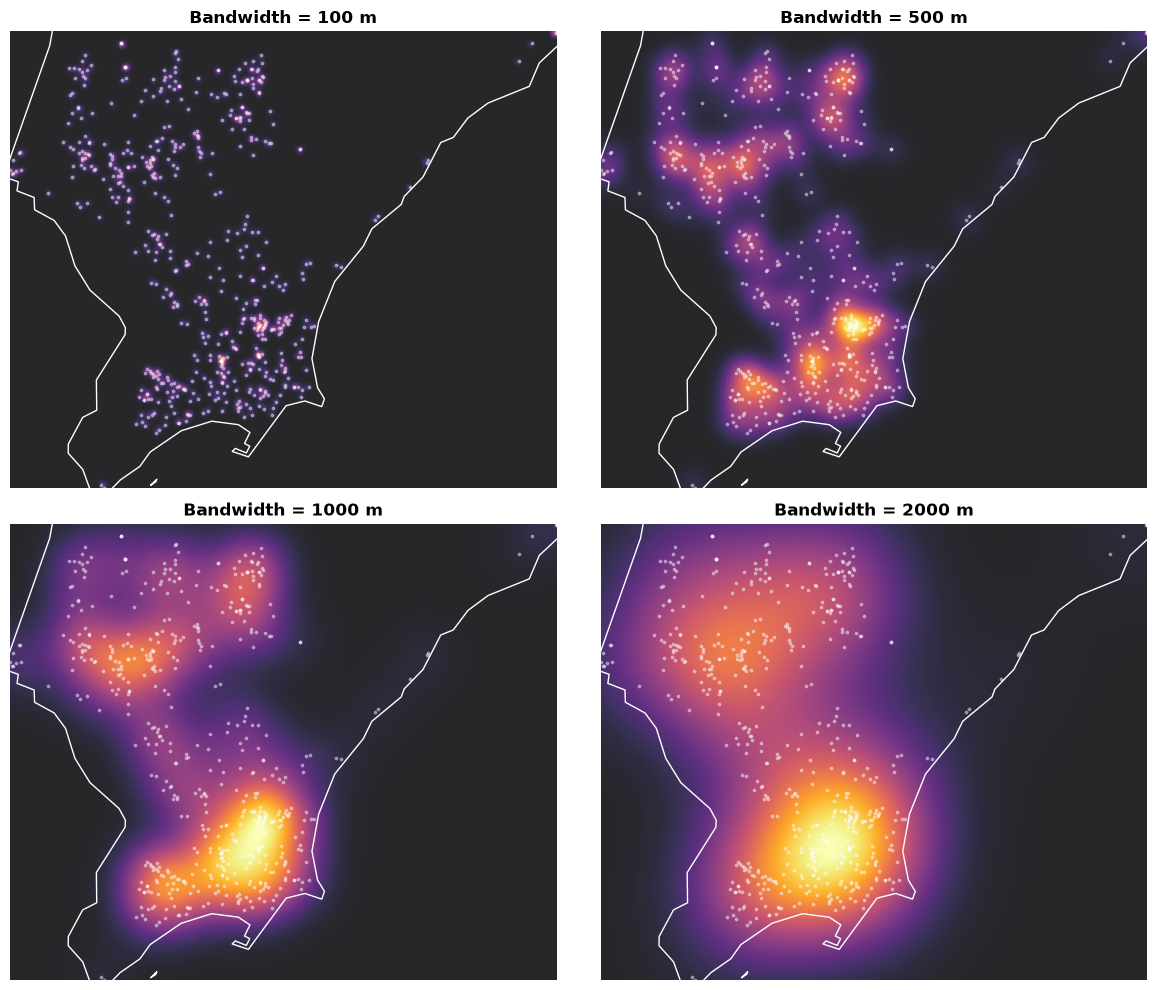

In [ ]:
from sklearn.neighbors import KernelDensity

# 
coords = np.column_stack([
    escolas_proj.geometry.x.values,
    escolas_proj.geometry.y.values
])

# Spatial extent
xmin, ymin, xmax, ymax = escolas_proj.total_bounds

# primeiro cria-se um grid 2-dimensional (lembra que essa função de KDE utiliza uma superfície e não um vetor 1d )
grid_x, grid_y = np.meshgrid(
    np.linspace(xmin, xmax, 200),
    np.linspace(ymin, ymax, 200)
)

# ajeita a entrada para dar um match com o input esperado pela funcao
grid_coords = np.column_stack([
    grid_x.ravel(),
    grid_y.ravel()
])

# bandwidths to compare
bandwidths = [100, 500, 1000, 2000]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

for ax, bandwidth in zip(axes.ravel(), bandwidths):

    # cria a classe
    kde = KernelDensity(
        bandwidth=bandwidth,
        kernel="gaussian",
        metric="euclidean"
    )

    # fit
    kde.fit(coords)

    # Estimate density
    log_density = kde.score_samples(grid_coords)

    densidade_grid = np.exp(log_density).reshape(grid_x.shape)

    # Plot KDE
    ax.imshow(
        densidade_grid,
        cmap="inferno",
        alpha=0.85,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower"
    )

    # Maceió boundary
    maceio.to_crs(CRS_PROJETADO).boundary.plot(
        ax=ax,
        color="white",
        linewidth=1
    )

    # School locations
    escolas_proj.plot(
        ax=ax,
        markersize=3,
        color="white",
        alpha=0.4
    )

    ax.set_title(
        f"Bandwidth = {bandwidth} m",
        fontsize=12,
        fontweight="bold"
    )
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f"Bandwidth = {bandwidth} m", fontsize=12, fontweight="bold")

    ax.set_axis_off()

plt.tight_layout()
plt.show()

A escolha do bandwidth é um aspecto importante da estimação por KDE, pois determina a escala espacial na qual os pontos são suavizados. Bandwidths menores produzem superfícies mais sensíveis a concentrações locais, enquanto valores maiores produzem superfícies mais suaves, destacando padrões espaciais de maior escala. Para ilustrar esse efeito, foram estimadas superfícies de densidade para as escolas utilizando diferentes valores de bandwidth. Observa-se que, à medida que o bandwidth aumenta, concentrações locais são progressivamente suavizadas e agrupamentos espacialmente próximos passam a formar regiões de densidade mais amplas.

Assim, o mapa de calor deve ser interpretado considerando que a identificação das áreas de maior concentração depende não apenas da distribuição dos equipamentos, mas também da escala espacial de suavização adotada na estimação da densidade.

A mesma ideia dá pra fazer de forma interativa com o plugin `HeatMap` do folium

In [10]:
from folium.plugins import HeatMap

m_calor = folium.Map(
    location=[maceio.iloc[0].geometry.centroid.y, maceio.iloc[0].geometry.centroid.x],
    zoom_start=12,
    tiles="OpenStreetMap",
)

HeatMap(
    [[pt.y, pt.x] for pt in escolas.geometry],
    name="Calor: escolas",
    radius=12,
).add_to(m_calor)

HeatMap(
    [[pt.y, pt.x] for pt in pontos_onibus.geometry],
    name="Calor: pontos de ônibus",
    radius=12,
    gradient={0.2: "#2a78d6", 0.5: "#f4a261", 1: "#e63946"},
).add_to(m_calor)

folium.LayerControl().add_to(m_calor)
m_calor

## Malha viária e grafos via  OSM

Aqui uma breve demonstração de como acessar os dados da OSM de malha viária.

### Dados da OSM

Vamos calcular algumas analises referente a essa ideia proposta por Tobler com os dados da Open Street Map. Vamos puxar a malha viária real do OpenStreetMap ao redor do centro de Sinop com `osmnx`, que baixa e já devolve um grafo (`networkx`) pronto pra análise de rede.

Antes disso, precisamos elencar o que é um grafo.

> "a Graph is a collection of nodes (vertices) along with identified pairs of nodes (called edges, links, etc). In NetworkX, nodes can be any hashable object e.g., a text string, an image, an XML object, another Graph, a customized node object, etc." [Networkx package](https://networkx.org/documentation/stable/tutorial.html)

Os grafos também possuem attributos, assim como as tabelas geoespaciais do geopandas

In [ ]:
G = ox.graph_from_point((-11.8642, -55.5089), dist=2500, network_type="drive")

# aqui uma funcao que converte esses grafos em um bem rememorado geodataframe para nos
nodes, edges = ox.graph_to_gdfs(G)

print(f"{len(nodes)} nós, {len(edges)} trechos de via")

2108 nós, 5128 trechos de via


In [29]:
G.graph

{'created_date': '2026-08-27 16:41:28',
 'created_with': 'OSMnx 2.1.1',
 'crs': 'epsg:4326',
 'simplified': True}

<Axes: >

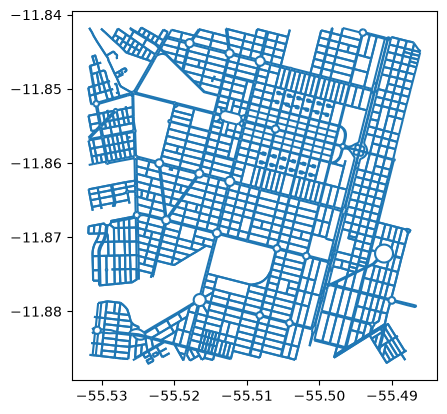

In [33]:
edges.plot()

In [34]:
nodes

,y,x,street_count,highway,geometry
osmid,,,,,
1426871464,-11.847788,-55.502623,3,NaN,POINT (-55.50262 -11.84779)
1426889293,-11.882949,-55.517499,3,NaN,POINT (-55.5175 -11.88295)
1426889299,-11.869990,-55.514106,3,NaN,POINT (-55.51411 -11.86999)
1426889308,-11.867333,-55.520733,3,NaN,POINT (-55.52073 -11.86733)
1426889358,-11.866781,-55.520333,3,NaN,POINT (-55.52033 -11.86678)
...,...,...,...,...,...
14101219950,-11.869503,-55.530329,4,NaN,POINT (-55.53033 -11.8695)
14101219952,-11.868245,-55.530170,3,NaN,POINT (-55.53017 -11.86825)
14101219953,-11.869519,-55.531077,3,NaN,POINT (-55.53108 -11.86952)


Cada nó já vem com `street_count` de quantas ruas se encontram ali. 
Isso nos dá interseções (`street_count >= 3`) e becos sem saída (`street_count == 1`) de graça, sem precisar calcular nada na mão:

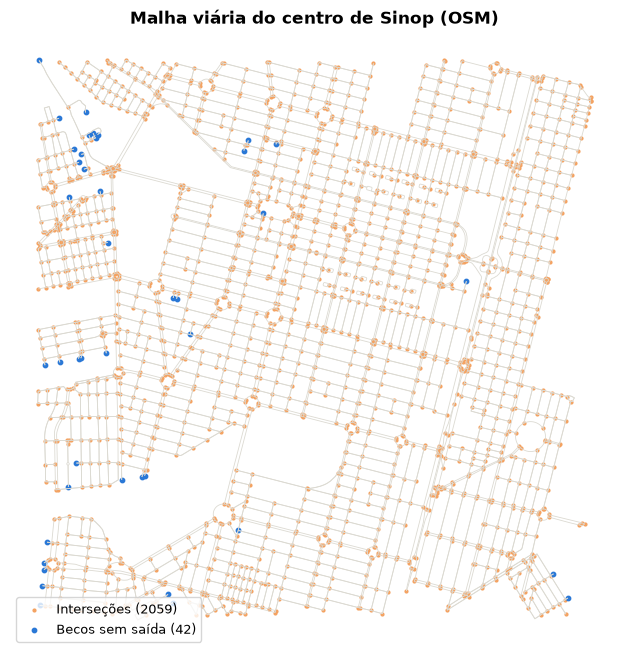

In [ ]:
#| label: fig-osm-intersections
#| fig-cap: "Malha viária do centro de Sinop: interseções reais (3+ vias) em laranja, becos sem saída em azul."

intersecoes = nodes[nodes["street_count"] >= 3]
becos_sem_saida = nodes[nodes["street_count"] == 1]

fig, ax = plt.subplots(figsize=(8, 8))
edges.plot(ax=ax, color="#dcdad2", linewidth=0.6)
intersecoes.plot(ax=ax, 
                 markersize=4, 
                 color="#f4a261", 
                 label=f"Interseções ({len(intersecoes)})"
                 )
becos_sem_saida.plot(ax=ax, 
                     markersize=10, 
                     color="#2a78d6", 
                     label=f"Becos sem saída ({len(becos_sem_saida)})")
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Malha viária do centro de Sinop (OSM)", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

::: {.callout-tip appearance="simple"}
Repare como o R do índice de vizinho mais próximo e o mapa de calor contam a mesma história de duas formas diferentes: um resume tudo num único número, o outro mostra *onde* especificamente a concentração acontece.
:::

## Referências

- Vuolo, F.; et al. — [Python for Geographic Data Science, cap. 6: Nearest neighbour analysis](https://python-gis-book.readthedocs.io/en/develop/part2/chapter-06/nb/07-nearest-neighbour.html)
- Tobler, W. R. (1970). *A computer movie simulating urban growth in the Detroit region*. Economic Geography, 46(sup1), 234–240.
- Clark, P. J.; Evans, F. C. (1954). *Distance to nearest neighbor as a measure of spatial relationships in populations*. Ecology, 35(4), 445–453.
- [GeoPandas — `sjoin_nearest`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.sjoin_nearest.html)
- [SciPy — `cKDTree`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html)
- [folium.plugins.HeatMap](https://python-visualization.github.io/folium/latest/user_guide/plugins/heatmap.html)
- [OSMnx documentation](https://osmnx.readthedocs.io/)

A partir da nossa análise espacial, concluímos que no munícipio de Sinop, as escolas rurais estão, em média, bem mais longe do estabelecimento de saúde mais próximo. Em média, caso um acidente num ambiente escolar aconteça, as escolas da área rural estão a pelo menos 700 metros a mais de uma unidade de saúde comparado as escolas numa área urbana. Esse tipo de análise, é possível quando elencamos nosso conhecimento em manipulação dos dados espaciais: Topologia, Geopandas, transformações, projeções, buffers, análise de distância e agregações espaciais. 

Algumas questões que pairam no ar? Como conseguimos analisar as densidades espaciais e entender a respeito de demanda? proximidade? 

O ecossistema geoespacial nos permite ir muito mais além, e veremos isso com mais calma na nossa próxima aula. 


## Referências

- Lovelace, R.; Nowosad, J.; Muenchow, J. — [Geocomputation with R, cap. 8: Spatial operations](https://r.geocompx.org/spatial-operations#spatial-aggr)
- [geobr](https://github.com/ipea/geobr) — dados oficiais geolocalizados do Brasil (IBGE, INEP, CNES)
- [OSMnx](https://osmnx.readthedocs.io/) — download e análise de redes urbanas do OpenStreetMap
- [H3 — Uber's Hexagonal Hierarchical Spatial Index](https://h3geo.org/)
- [IPEA Data](http://www.ipeadata.gov.br/) — séries históricas socioeconômicas do Brasil